# Assignment: Clustering and association rule mining

## Objectives

The objectives of this assignment are:
1.	to learn to use kNN and other clustering techinques to split data into groups based on similarity of features
2. to learn to use association rule mining to find interesting relationships between variables

## Setup

This assignment focuses on a drone delivery company that is looking to optimize its operations. The company has a fleet of drones that deliver products to customers.
The company intends to create a set of hubs, or depots, where the drones are stationed, serviced, and loaded with products for delivery.
The company is looking to optimize its operations by finding the optimal locations for its hubs.

> For a real life example of such a delivery system, see the website of Amazon Prime Air: [https://www.aboutamazon.
> com/news/tag/prime-air](https://www.aboutamazon.com/news/tag/prime-air). Neither the assignment nor the data sets 
> provided are not related to this 
> company in any way.

Another optimization idea is to increase the revenue of the company by recommending products to customers based on their purchase history. For this purpose, the company is looking to use association rule mining to find interesting relationships between products that are frequently purchased together.
In the initial phase of the project, the company focuses on 20 internal product groups, and wants to find out which product groups act as triggers for buying items from some other product groups.

There are two datasets that are provided for this assignment:

1. [drone_cust_locations.csv](../datasets/drone_delivery/drone_cust_locations.csv) - This dataset contains the 
   locations of customers. The dataset has the 
   following 
   columns:
    - `clientid` - The unique identifier for the customer
    - `x` - The x coordinate of the customer's location, when plotted into a 2D plane
    - `y` - The y coordinate of the customer's location, when plotted into a 2D plane
    
2. [drone_prod_groups.csv](../datasets/drone_delivery/drone_prod_groups.csv) - This dataset contains the sales data for products. The 
   dataset has the 
   following 
   columns:
    - `ID` - The transaction ID
    - `Prod1, ..., Prod20` - Binary variables indicating whether at least one product from a particular group was 
      purchased 
      in the transaction. A value of 1 indicates that at least one product from the group was purchased, while a value of 0 indicates that no products from the group were purchased.

## Task

The task is split into two sub-tasks: finding optimal hub locations and finding interesting relationships between product groups.

### Part 1: Finding optimal hub locations

Guidelines for the Analysis phase:

1. Visualize the client locations by making a two-dimensional scatterplot. Can you give a geographic interpretation for what you see?
Using k-means clustering, find optimal locations (i.e. x and y
coordinates) for three drone depots. Each depot should serve its
surrounding clients.

>Hint: you can use Seaborn https://seaborn.pydata.org/generated/seaborn.scatterplot.html
or Matplotlib: https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html.

>Hint: The centroids serve as the depot locations. You will later need to change the number
of depots, so design your program in such a way that you just need to modify a single
value to do that.

2. Attach the information on the closest depot to each client. That is, generate a data
frame that is similar to the original one with the exception that it has an additional
column that contains the identifier of the depot nearest to the client. Print the first 10
rows of the new data frame.

3. Make a scatterplot that uses three different colours. The markers with the same colour
are served by the same depot.
Hint: Re-check the web page(s) mentioned in the first task.

4. Play with the number of depots. What are the optimal locations for 10 depots, for
example? Do you see a difference in the computation time when the number of depots
increases?

5. Replace k-means with agglomerative hierarchical clustering and explore it with various
depot numbers. What are your observations?

In the end, your report should give a recommendation on how the depots should be placed, depending on the number of depots.
You should also discuss the differences between k-means and hierarchical clustering in this context.

### Part 2: Finding interesting relationships between product groups

Use association rule mining to find interesting relationships between product groups.

Your report should include a clear recommendation on how the company should use the results of the association rule mining to increase its revenue.

## Deliverables

Submit a GitHub permalink that points to the Jupyter notebook as instructed in Oma. The submitted notebook must contain the problem analysis written in accordance with the CRISP-DM process model, complete with Markdown blocks and comments that clearly explain what has been done.

## 1. Business understanding

The goal of this project is to optimize the operations and increase revenue of a done delivery company using spatial clustering and association rule mining.

The project involves 2 separate tasks that are explained below.

1. Optimal drone hub locations.

2. Product group recommendations.

## 2. Data understanding

### 2.1 Importing the data



In [17]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [18]:
df_drone_cust_loc = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')
df_drone_prod_groups = pd.read_csv('datasets/drone_prod_groups.csv')

In [19]:
# Dataset containing the locations of customers
df_drone_cust_loc.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


In [147]:
# Dataset containing sales data of products
df_drone_prod_groups.head()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


### 2.x. Visualization

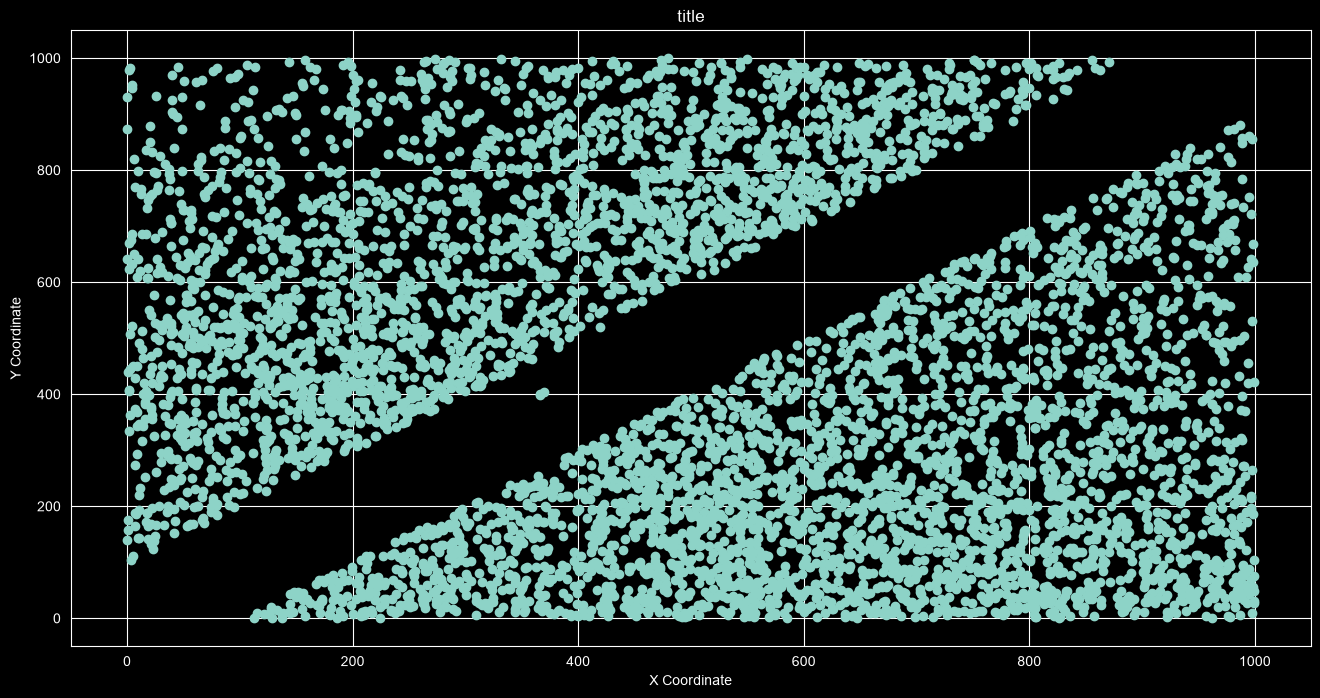

In [21]:
plt.figure(figsize=(16, 8))

plt.scatter(df_drone_cust_loc["x"], df_drone_cust_loc["y"])
plt.title("title")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

## 3. Data Preparation


### 3.1 Feature Selection for Spatial Clustering & Transaction Matrix Setup

Preparing the data for modeling requires 2 things first:

1. **Clustering Feature Matrix (`X_cust`):** We extract `x` and `y` coordinates into a separate DataFrame `X_cust`. The `clientid` column is kept in `df_drone_cust_loc` so assigned depot IDs can be attached back to individual clients.
2. **Basket Transaction Matrix (`X_prod`):** We extract the binary product columns (`Prod1` through `Prod20`) by dropping the `ID` column.

In [22]:
# 1. Clustering Matrix (Spatial coordinates only)
X_cust = df_drone_cust_loc[['x', 'y']]

print("\nClustering Features (X_cust):")
X_cust.head(5)


Clustering Features (X_cust):


,x,y
0,622.771572,164.857623
1,416.357298,630.193634
2,292.735020,567.333231
3,737.211288,166.225676
4,540.475375,682.912298


In [23]:
# 2. Transaction Basket Matrix (Binary product features only)
X_prod = df_drone_prod_groups.drop(columns=['ID']).astype(bool)

print("\nProduct Basket Matrix (X_prod):")
X_prod.head(5)


Product Basket Matrix (X_prod):


,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True


In [24]:
print("\nData Preparation Completed:")
print(f"Clustering Features Shape: {X_cust.shape}")
print(f"Product Basket Matrix Shape: {X_prod.shape}")



Data Preparation Completed:
Clustering Features Shape: (5956, 2)
Product Basket Matrix Shape: (100000, 20)


### 3.2 Interpretation

Both datasets were prepared cleanly without data loss.

From `X_cust`, the `clientid` was excluded to ensure arbitrary identification numbers do not distort the distance calculations during **K-Means or Hierarchical clustering**

`X_prod` was cast to boolean types as required by `mlxtend` for fast Apriori pattern generation.

## 4. Modeling

### 4.1 Finding Optimal Hub Locations

#### 4.1.1 Clustering the Data

There are a number of ways to identify the optimum number of clusters. The method below is known as the Elbow method.

The Elbow plot allows to plot the inertia, which is a measure of how well the data was clustered by the K-Means algorithm, against the number of clusters. From this plot, we are looking for a point where the inertia begins to slow.

In [ ]:
# Function to work out optimum number of clusters.

def optimise_k_means(data, max_k):
    means = []
    inertias = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=10,
            random_state=21
            )
        kmeans.fit(data)

        means.append(k)
        inertias.append(kmeans.inertia_)

    # Generate the Elbow plot
    fig=plt.subplots(figsize=(10, 5))
    plt.plot(means, inertias, 'o-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

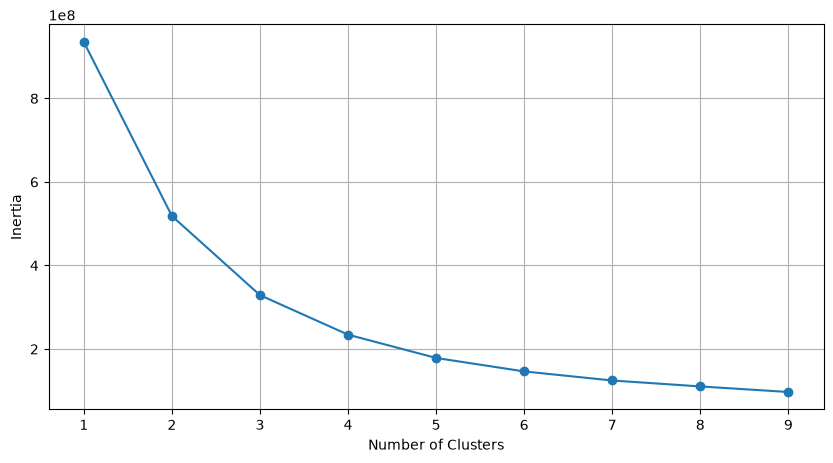

In [82]:
optimise_k_means(X_cust[['x', 'y']], 10)

#### 4.1.2 Applying K-Means Clustering


Setting $N\_DEPOTS = 3$ as a configurable parameter, fitting $K$-Means, and assigning each client to their nearest depot.

In [92]:
N_DEPOTS = 3

kmeans = KMeans(
    n_clusters=N_DEPOTS,
    init='k-means++',
    random_state=21
    )

# Fit the model on your data
kmeans.fit(X_cust)

# Predict cluster assignments using the fitted model
df_drone_cust_loc['kmeans_3'] = kmeans.predict(X_cust)

# Extract depot coordinates (centroids)
depot_locations = pd.DataFrame(
    kmeans.cluster_centers_, 
    columns=['x', 'y']
)
depot_locations.index.name = 'depot_id'

print("Drone Depot Coordinates (Centroids) for K = 3")
display(depot_locations)

print("\nFirst 10 Rows of Client Data with Assigned Depot")
df_drone_cust_loc.head(10)

Drone Depot Coordinates (Centroids) for K = 3


,x,y
depot_id,,
0,198.536354,382.885756
1,548.006019,787.243816
2,702.213116,211.327341



First 10 Rows of Client Data with Assigned Depot


,clientid,x,y,kmeans_3,nearest_depot
0,1,622.771572,164.857623,2,2
1,2,416.357298,630.193634,1,1
2,3,292.735020,567.333231,0,0
3,4,737.211288,166.225676,2,2
4,5,540.475375,682.912298,1,1
5,6,535.469492,318.439661,2,2
6,7,640.380050,870.833221,1,1
7,8,235.772075,359.048203,0,0
8,9,481.896884,661.491838,1,1
9,10,730.032789,312.177817,2,2


#### 4.1.3 Plotting the Results

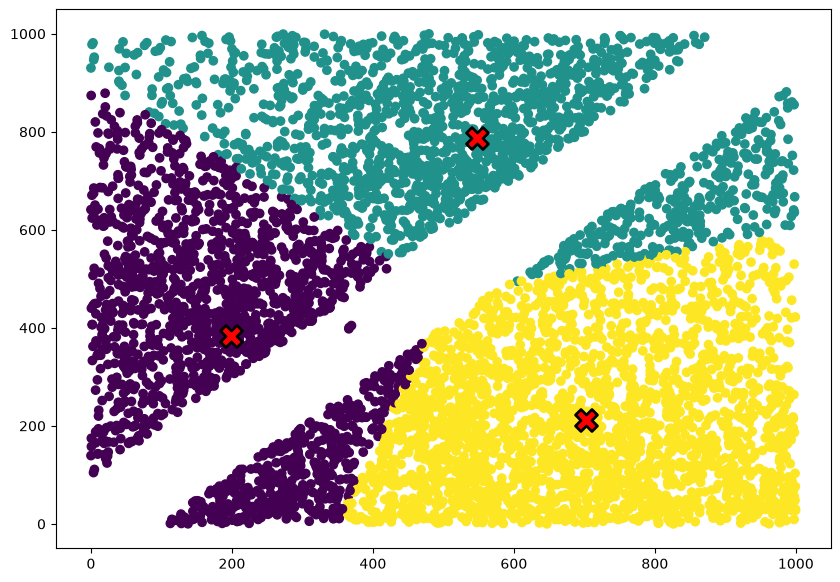

In [96]:
plt.figure(figsize=(10, 7))

plt.scatter(
    x=df_drone_cust_loc['x'], 
    y=df_drone_cust_loc['y'], 
    c=df_drone_cust_loc['kmeans_3'],
    )


# Mark the depot centroids as X markers
plt.scatter(
    x=depot_locations['x'],
    y=depot_locations['y'],
    color='red',
    marker='X',
    s=250,
    linewidths=2,
    edgecolor='black',
    label='Depot Location (Centroid)'
)

plt.show()

### 4.2 Finding Interesting Relationships Between Product Groups
Association rules were analyzed with the Apriori algorithm implementation from Machine Learning Library Extensions (mlxtend).

Product data was prepared to boolean format for this algorithm in chapter 3.

In [27]:
# TODO: task:  Use association rule mining to find interesting relationships between product groups.

#### 4.2.1 Support
Support is the proportion of purchases that contain the item set. It can be used to identify popular items.

In [193]:
# Import Machine Learning Library Extensions (mlxtend) for Apriori algorithm
from mlxtend.frequent_patterns import apriori, association_rules

# Sort item sets by support TODO: min_support value filters the dataset heavily, what value is reasonable?
min_support_value = 0.01 # value of 0.1 leaves only 4 rules
frequent_itemsets = apriori(X_prod, min_support=min_support_value, use_colnames=True, max_len=None)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
print(f'Item sets that are present in >={min_support_value * 100}% of purchases:')
frequent_itemsets

Item sets that are present in >=1.0% of purchases:


,support,itemsets
18,0.20626,frozenset({ Prod19})
8,0.19853,frozenset({ Prod9})
7,0.16179,frozenset({ Prod8})
11,0.15971,frozenset({ Prod12})
19,0.14798,frozenset({ Prod20})
...,...,...
127,0.01047,"frozenset({ Prod17, Prod20})"
154,0.01042,"frozenset({ Prod19, Prod12, Prod9})"
109,0.01034,"frozenset({ Prod12, Prod17})"
142,0.01033,"frozenset({ Prod12, Prod5, Prod18})"


#### 4.2.2 Confidence
Confidence measures the proportion of purchases that also have the consequent item set, when the antecedent item set is present. It could be used to recommend additional items when a customer selects one.

In [194]:
# Generate association rules
min_confidence_value = 0.1
a_rules_confidence : DataFrame = association_rules(frequent_itemsets, metric='confidence', min_threshold=min_confidence_value)

# Sort rules by confidence
a_rules_confidence = a_rules_confidence.sort_values(by='confidence', ascending=False)
a_rules_confidence

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
250,"frozenset({ Prod2, Prod15})",frozenset({ Prod9}),0.01947,0.19853,0.01843,0.946584,4.767967,1.0,0.014565,15.004443,0.805959,0.092349,0.933353,0.519708
176,"frozenset({ Prod20, Prod15})",frozenset({ Prod9}),0.02241,0.19853,0.02119,0.945560,4.762807,1.0,0.016741,14.722084,0.808150,0.106083,0.932075,0.526147
225,"frozenset({ Prod19, Prod20, Prod15})",frozenset({ Prod9}),0.02030,0.19853,0.01919,0.945320,4.761599,1.0,0.015160,14.657514,0.806356,0.096123,0.931776,0.520990
160,"frozenset({ Prod12, Prod15})",frozenset({ Prod9}),0.02308,0.19853,0.02173,0.941508,4.742396,1.0,0.017148,13.702169,0.807780,0.108715,0.927019,0.525481
237,"frozenset({ Prod7, Prod15})",frozenset({ Prod9}),0.02014,0.19853,0.01895,0.940914,4.739403,1.0,0.014952,13.564375,0.805220,0.094883,0.926277,0.518183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,frozenset({ Prod20}),"frozenset({ Prod19, Prod10})",0.14798,0.02289,0.01533,0.103595,4.525779,1.0,0.011943,1.090032,0.914349,0.098560,0.082596,0.386660
408,frozenset({ Prod5}),"frozenset({ Prod12, Prod7})",0.10459,0.02586,0.01083,0.103547,4.004145,1.0,0.008125,1.086661,0.837894,0.090537,0.079750,0.261170
300,frozenset({ Prod12}),"frozenset({ Prod19, Prod5})",0.15971,0.02610,0.01643,0.102874,3.941531,1.0,0.012262,1.085578,0.888136,0.097001,0.078831,0.366188
312,frozenset({ Prod12}),"frozenset({ Prod9, Prod5})",0.15971,0.02462,0.01608,0.100682,4.089459,1.0,0.012148,1.084578,0.899057,0.095572,0.077982,0.376905


#### 4.2.3 Lift

Lift metric is the factor by which the probability of the consequent item set increases when the antecedent set is present.
It could be used to decide what products to recommend or bundle, or adjust the pricing of bundles.

In [195]:
# Generate association rules
a_rules_lift : DataFrame = association_rules(frequent_itemsets, metric='lift', min_threshold=1)

# Sort rules by lift
a_rules_lift = a_rules_lift.sort_values(by='lift', ascending=False)
a_rules_lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
236,"frozenset({ Prod20, Prod9})","frozenset({ Prod19, Prod15})",0.03676,0.03041,0.01919,0.522035,17.166551,1.0,0.018072,2.028579,0.977687,0.399958,0.507044,0.576539
233,"frozenset({ Prod19, Prod15})","frozenset({ Prod20, Prod9})",0.03041,0.03676,0.01919,0.631042,17.166551,1.0,0.018072,2.610707,0.971284,0.399958,0.616962,0.576539
235,"frozenset({ Prod20, Prod15})","frozenset({ Prod19, Prod9})",0.02241,0.04996,0.01919,0.856314,17.139995,1.0,0.018070,6.611924,0.963243,0.360850,0.848758,0.620211
234,"frozenset({ Prod19, Prod9})","frozenset({ Prod20, Prod15})",0.04996,0.02241,0.01919,0.384107,17.139995,1.0,0.018070,1.587273,0.991176,0.360850,0.369989,0.620211
423,"frozenset({ Prod20, Prod5})","frozenset({ Prod19, Prod12})",0.01888,0.03881,0.01101,0.583157,15.025941,1.0,0.010277,2.305879,0.951411,0.235861,0.566326,0.433423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,frozenset({ Prod18}),frozenset({ Prod11}),0.12166,0.10848,0.01548,0.127240,1.172934,1.0,0.002282,1.021495,0.167859,0.072114,0.021043,0.134969
125,frozenset({ Prod14}),frozenset({ Prod7}),0.14557,0.13499,0.02296,0.157725,1.168418,1.0,0.003310,1.026992,0.168700,0.089130,0.026283,0.163906
124,frozenset({ Prod7}),frozenset({ Prod14}),0.13499,0.14557,0.02296,0.170087,1.168418,1.0,0.003310,1.029541,0.166636,0.089130,0.028694,0.163906
463,frozenset({ Prod17}),frozenset({ Prod12}),0.05618,0.15971,0.01034,0.184051,1.152409,1.0,0.001367,1.029832,0.140125,0.050304,0.028968,0.124397


#### 4.2.4 Visualization
Plotting the support of products, and confidence and lift values of association rules can help identify which products to focus on during evaluation.

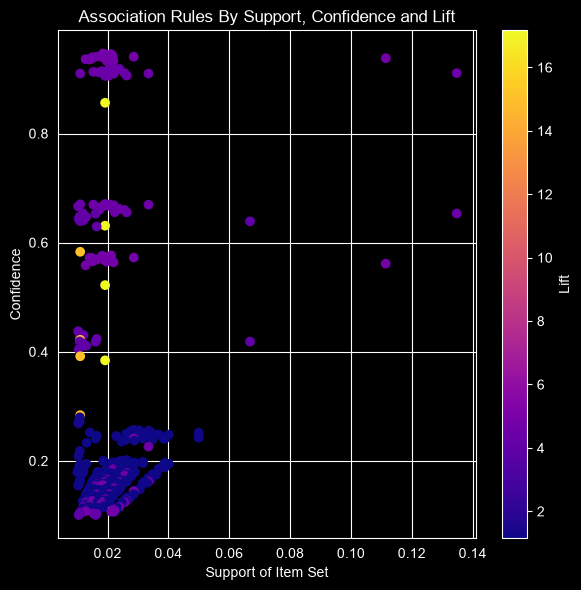

In [196]:
ruleset = a_rules_confidence
plt.figure(figsize=(6, 6))
scatter = plt.scatter(x=ruleset['support'], y=ruleset['confidence'],c=ruleset['lift'], cmap='plasma')

plt.colorbar(scatter, label='Lift')
plt.xlabel('Support of Item Set')
plt.ylabel('Confidence')
plt.title('Association Rules By Support, Confidence and Lift')

plt.tight_layout()
plt.show()

## 5. Evaluation

### 5.1 Depot Placement Analysis and Recommendation

In [197]:
#TODO: task: In the end, your report should give a recommendation on how the depots should be placed, depending on the number of depots. You should also discuss the differences between k-means and hierarchical clustering in this context.

### 5.2 Association Rule Mining Result Analysis and Recommendation

In [198]:
# TODO: task: Your report should include a clear recommendation on how the company should use the results of the association rule mining to increase its revenue.

# TODO: are there nice tables for this?

## 6. Deployment